In [ ]:
!pip install windpowerlib

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from windpowerlib import data as wt
from windpowerlib import TurbineClusterModelChain, WindTurbine, WindFarm, ModelChain

In [ ]:
weather_data= pd.read_csv('weather_montreal.csv',  index_col = 0,header = [0,1]) # To consider datetime as index and the first two rows as headers
weather_data.index = pd.to_datetime(weather_data.index, utc=True) # To convertweather_data the datetime format
weather_data

In [ ]:
turbine_lib = wt.get_turbine_types(print_out = False) # Because the data is not that good looking
turbine_lib # Printing this would give a good data

In [7]:
selected_turbine = {'turbine_type':'E48/800', 'hub_height': 60}
wind_turbine = WindTurbine(**selected_turbine)

In [8]:
wind_turbine_fleet = pd.DataFrame({'wind_turbine': [wind_turbine, None],    # Incase you want to add other type of wind turbine define them like in previous cell and input them here
                                   'number_of_turbines': [10, None],})       # Even here you can mention the number of other wind turbines
                                   # 'total_capacity': [8000, None]})       # Use this incase you don't have number of turbines, but you know the total capacity

In [9]:
farm_data = {
    'wind_turbine_fleet': [wind_turbine.to_group(10)], # This is doing he same as what previous cell does. You can comment them
    'efficiency': 0.9
}

farm_data_2 = WindFarm(**farm_data)

In [17]:
Wind_Farm_Sub_Models = {
    'wake_losses_model': 'dena_mean',                        # 'dena_mean' (default), 'knorr_mean', 'dena_extreme1', 'dena_extreme2', 'knorr_extreme1', 'knorr_extreme2', 'knorr_extreme3'
    'smoothing' : True,                                       # 'True' (refer slides for equation), 'False' (default)
    'standard_deviation_method': 'turbulence_intensity',      # 'turbulence_intensity', 'Staffel_Pfenniger

    # Rest all are same as that of single turbine model
    'wind_speed_model' : 'hellman',                           #'hellman','logerithmic'(default), 'interpolation-exterpolation'
    'density_model' : 'ideal_gas',                            #'Barometric'(default) ,'ideal_gas', 'interpolation-exterpolation'
    'temperature_model' : 'linear_gradient',                  #'linear_gradient', 'interpolation-exterpolation'
    'power_output_model' : 'power_curve',                     #'power_curve' (default)
    'density_correction' : True,                              #True, False (default)
    'obstacle_height': 0,                                     # Imagine no obstrucle, if you have any put the height of it (default is 0)
    'hellman_exp' : 0.25                                      # refer the lecture notes for friction values for various terrains (default is 9)
    }

In [ ]:
Model_Farm = TurbineClusterModelChain(farm_data_2, **Wind_Farm_Sub_Models).run_model(weather_data)

Farm_Power_Output = (Model_Farm.power_output) / 10**3 # To get the output in [kW]
Farm_Power_Output

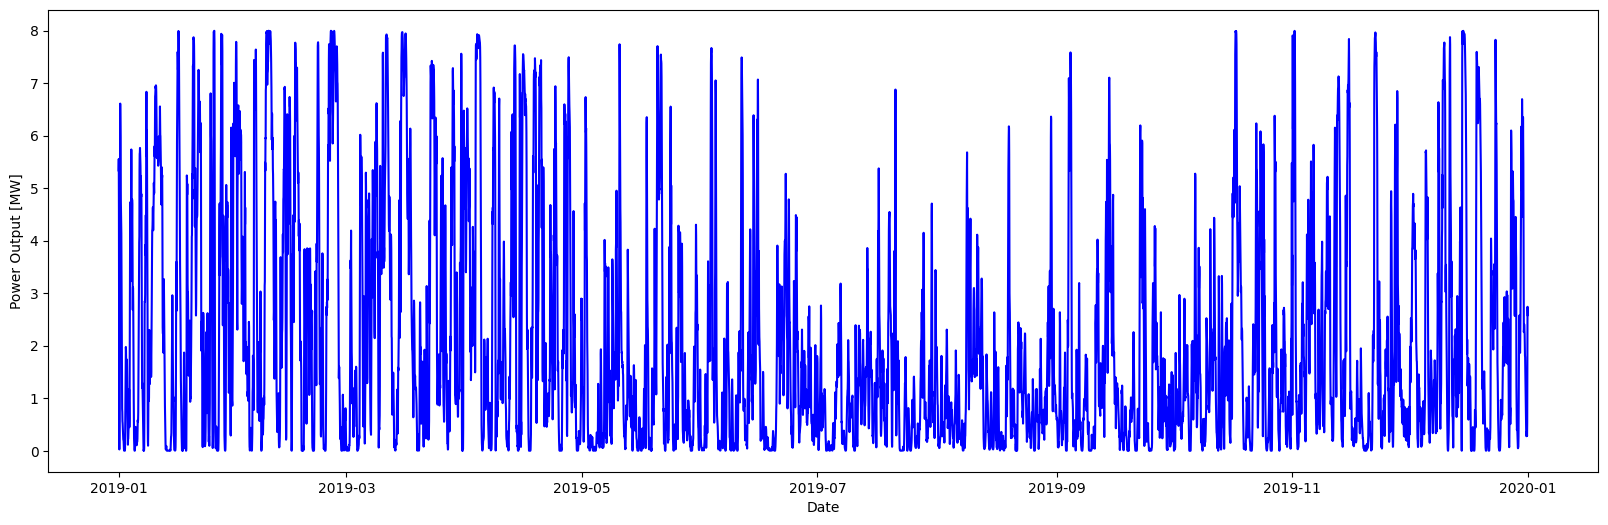

In [23]:
plt.figure(figsize=(20,6))
plt.plot(Farm_Power_Output, color = 'blue')
plt.xlabel("Date")
plt.ylabel("Power Output [MW]")
plt.show()

**Comparing the results from single wind turbine and wind farm**

In [25]:
selected_turbine = {'turbine_type':'E48/800', 'hub_height': 60}
wind_turbine = WindTurbine(**selected_turbine)

In [26]:
Turbine_Sub_Models = {
    'wind_speed_model' : 'hellman',                           #'hellman','logerithmic'(default), 'interpolation-exterpolation'
    'density_model' : 'ideal_gas',                            #'Barometric'(default) ,'ideal_gas', 'interpolation-exterpolation'
    'temperature_model' : 'linear_gradient',                  #'linear_gradient', 'interpolation-exterpolation'
    'power_output_model' : 'power_curve',         #'power_curve' (default), 'power_coefficient_curve'
    'density_correction' : True,                              #True, False (default)
    'obstacle_height': 0,                                     # Imagine no obstrucle, if you have any put the height of it (default is 0)
    'hellman_exp' : 0.25                                      # refer the lecture notes for friction values for various terrains (default is 9)
    }

In [27]:
model = ModelChain(wind_turbine, **Turbine_Sub_Models).run_model(weather_data)

In [ ]:
Turbine_Power_Output = (model.power_output) / 1000 # To covert from [W] to [kW]
Turbine_Power_Output

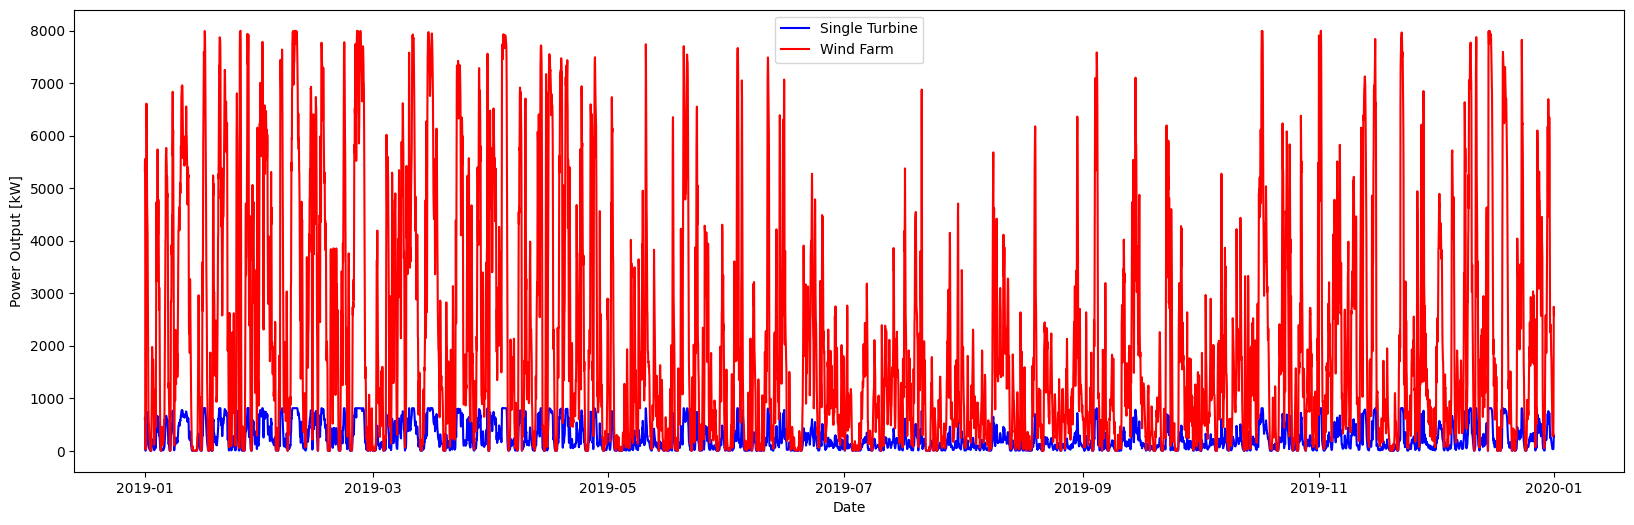

In [30]:
plt.figure(figsize=(20,6))
plt.plot(Turbine_Power_Output, color = 'blue', label = "Single Turbine")
plt.plot(Farm_Power_Output, color = 'red', label = "Wind Farm")
plt.xlabel("Date")
plt.ylabel("Power Output [kW]")
plt.legend()
plt.show()